In [1]:
import numpy as np
import torch
from torch.distributions import HalfNormal, Uniform
from scipy import stats
from sbi.utils import BoxUniform, MultipleIndependent, mcmc_transform
from sbi.neural_nets import posterior_nn
import scipy
from sbi.inference import NPE, MCMCPosterior, posterior_estimator_based_potential, simulate_for_sbi
from sbi.neural_nets.embedding_nets import FCEmbedding, CNNEmbedding, PermutationInvariantEmbedding
from matplotlib import pyplot as plt

/home/lexi.leali/.conda/envs/sbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define simulator parameters
f_low = 10
f_high = 200
fref  = 25
pi = np.pi
sqrt = np.sqrt
H100 = 3.241e-18
h    = 0.679
H0   = h * H100
T_obs = 365 * 24 * 3600
Delta_f = 1/32.
N_bins = int((f_high - f_low) / Delta_f) + 1
freq = np.linspace(f_low, f_high, N_bins)   
psd = np.genfromtxt("data/cosmic_explorer_40km_for_paper.txt")
psd[0, 0]  = 4.99999999999999999
psd[:, 1] = psd[:, 1]**2
gamma = np.genfromtxt("data/gamma_HL.txt")
# Interpolations
psd_interp = scipy.interpolate.interp1d(psd[:, 0], psd[:, 1], fill_value="extrapolate")
gamma_interp = scipy.interpolate.interp1d(gamma[:, 0], gamma[:, 1], fill_value="extrapolate")
psd_vals = psd_interp(freq)
gamma_vals = gamma_interp(freq)

In [3]:
numerator = (20 * np.pi**2 * freq**3)**2 * psd_vals**2
denominator = (3 * H0**2)**2 * 8 * gamma_vals**2
T = 1 / (freq[1] - freq[0])
N = int(2 * T_obs // T - 1)
sigma = np.sqrt(numerator / denominator / N)

In [4]:
# --- Prior: both parameters live in \"inference space\" (scaled space) ---
prior = MultipleIndependent([HalfNormal( torch.tensor([1.0])),  # scaled Ω
        Uniform(torch.tensor([-3.0]), torch.tensor([3.0]))
                            ],validate_args=False)

In [5]:
# --- Descaling: from inference space → physical space ---
def descale_params(theta_scaled):
    """"
    Map theta_scaled = [Ω_scaled, α_scaled] from standard-normal space
    to the physical parameter space where Ω has σ=1e-8 and α is unchanged
    """
    omega_scaled = theta_scaled[:, 0]
    alpha = theta_scaled[:, 1]
    
    omega_physical = omega_scaled * 1e-8  # scale σ = 1 → σ = 1e-8
    return omega_physical, alpha

# --- Actual data simulator ---
def simulate_physical(omega_physical, alpha):
    """
    Generate noisy power spectra given physical parameters.
    """
    Omega_ref = omega_physical[:, None]
    alpha_term = (freq / fref)[None, :] ** alpha[:, None]
    C_true = Omega_ref * alpha_term
   
    rng = np.random.default_rng()
    C_noisy = C_true + rng.normal(0, sigma, size=C_true.shape)
    return torch.tensor(C_noisy, dtype=torch.float32)

# --- Actual physics simulator, no noise ---
def simulate_model(omega_physical, alpha):
    """
    Generate noisy power spectra given physical parameters.
    """
    Omega_ref = omega_physical[:, None]
    alpha_term = (freq / fref)[None, :] ** alpha[:, None]
    C_true = Omega_ref * alpha_term
   
    return torch.tensor(C_true, dtype=torch.float32)
    
# --- Wrapper for no noise ---
def simulator_no_noise(theta_scaled):
    """
    Wrapper compatible with sbi
    Accepts parameters from the scaled prior (N(0,1)),
    rescales Ω internally, leaves α unchanged, and returns simulated data.
    """
    
    theta_scaled = theta_scaled.detach().cpu().numpy()
    omega_physical, alpha = descale_params(theta_scaled)
    return simulate_model(omega_physical, alpha)


# --- Wrapper for sbi ---
def simulator(theta_scaled):
    """
    Wrapper compatible with sbi
    Accepts parameters from the scaled prior (N(0,1)),
    rescales Ω internally, leaves α unchanged, and returns simulated data.
    """
    
    theta_scaled = theta_scaled.detach().cpu().numpy()
    omega_physical, alpha = descale_params(theta_scaled)
    return simulate_physical(omega_physical, alpha)

    

In [6]:
# ------------------------
#Generate training simulations
# ------------------------#
num_simulations = 50_000
theta_train, x_train = simulate_for_sbi(simulator, prior, num_simulations=num_simulations)
print(theta_train.shape)  # (n_simulations, 2)
print(x_train.shape)      # (n_simulations, Nfreq)

100%|███████████████████████████████████| 50000/50000 [00:23<00:00, 2160.10it/s]


torch.Size([50000, 2])
torch.Size([50000, 6081])


In [7]:
embedding_net = FCEmbedding(input_dim=6081)
# Instantiate the conditional neural density estimator
neural_posterior = posterior_nn(model="maf", embedding_net=embedding_net)
# Setup the inference procedure with NPE
inference = NPE(density_estimator=neural_posterior)
density_estimator = inference.append_simulations(theta_train, x_train).train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 79 epochs.

In [8]:

#Create a single observation
theta_true = torch.tensor([[0.1, 1.5]])     # shape (1, 2)
x_obs= simulator(theta_true)          # shape (1, Nfreq)
# Ensure correct shape: leading batch dimension = 1
print(x_obs.shape)  # (1, Nfreq)
# 6. Condition posterior on observation
posterior = posterior.set_default_x(x_obs)
# 7. Sample from posterior
sbi_samples = posterior.sample((2000,))  # draws from p(theta | x_obs)
print(sbi_samples.shape)  # (2000, 2)

torch.Size([1, 6081])


100%|███████████████████████████████████| 2000/2000 [00:00<00:00, 189230.95it/s]

torch.Size([2000, 2])


In [9]:
x_obs_plot = x_obs.flatten()
x_obs_plot = x_obs_plot.numpy()

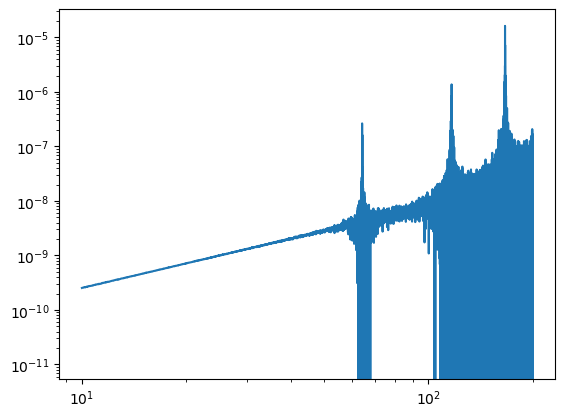

In [10]:
plt.loglog(freq, x_obs_plot)

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=/home/lexi.leali/sbi-logs/NPE_C/2025-11-12T19_46_56.531861' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


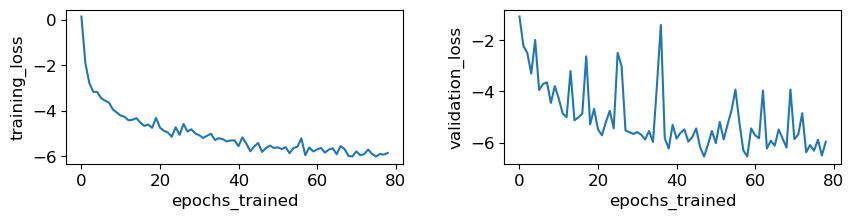

In [11]:
from sbi.analysis import plot_summary
# plot training loss
_ = plot_summary(inference, tags=["training_loss", "validation_loss"], figsize=(10, 2))
# All training logs are available in `trainer.summary

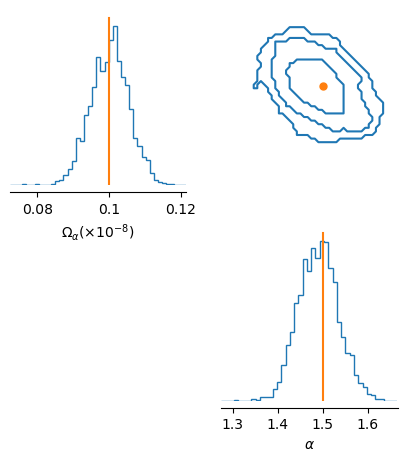

In [12]:
from sbi.analysis import pairplot
_ = pairplot(
    sbi_samples, points = theta_true[:], upper = 'contour',  figsize=(5, 5), 
    labels=[r"$\Omega_{\alpha} ( \times 10^{-8})$", r"$\alpha$"])

## Grid

In [13]:
Omega_vals = np.linspace(5e-14, 5e-8, 200)    # physical Ω grid
alpha_vals = np.linspace(-3, 3, 50)       # α grid
Omega_scaled = Omega_vals  /1e-8      # scaled Ω for the simulator, Omega_vals unscaled
# --- priors ---
prior_Omega = HalfNormal(1.0)
prior_alpha = Uniform(-3.0, 3.0)

In [14]:
theta_grid = np.stack(np.meshgrid(Omega_scaled, alpha_vals, indexing='ij'), -1).reshape(-1, 2)
theta_torch = torch.tensor(theta_grid, dtype=torch.float32)
models = simulator_no_noise(torch.tensor(theta_grid, dtype=torch.float32))

In [15]:
#logL = -0.5*torch.sum(((x_obs - models)**2 / sigma**2) , dim=1)

logL = -0.5 * torch.mean(((x_obs - models) / sigma) ** 2, dim=1)

#logP_Omega = prior_Omega.log_prob(theta_torch[:, 0])
#logP_alpha = prior_alpha.log_prob(theta_torch[:, 1])
#logP = logP_Omega + logP_alpha

/local/lexi.leali/ipykernel_2810516/3190304051.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  logL = -0.5 * torch.mean(((x_obs - models) / sigma) ** 2, dim=1)


In [16]:
log_post = logL #+ logP
# reshape back to 2D grid for plotting
log_post_grid = log_post.reshape(len(Omega_vals), len(alpha_vals))

In [17]:
# Make everything finite

log_post_grid_safe = log_post_grid.clone()
finite_mask = torch.isfinite(log_post_grid_safe)
if not finite_mask.all():
    if finite_mask.any():
        min_finite = torch.min(log_post_grid_safe[finite_mask])
    else:
        min_finite = torch.tensor(0)
        log_post_grid_safe[~finite_mask] = min_finite

In [18]:
logp = log_post_grid_safe.flatten().double()  # ensure float64 for safety
logZ = torch.logsumexp(logp, dim=0)
log_post_norm = logp - logZ
# exponentiate safely
posterior = torch.exp(log_post_norm)

# normalize to make it a proper probability distribution
posterior /= posterior.sum()

# Convert to numpy and normalize
log_post_grid_np = log_post_norm.cpu().numpy()



In [19]:
import pandas as pd


posterior_grid = posterior.reshape(len(Omega_vals), len(alpha_vals))

# --- sanity check ---
print("Sum over grid (should be ≈1):", posterior_grid.sum().item())
print("Posterior min/max:", posterior_grid.min().item(), posterior_grid.max().item())
# --- sample from posterior grid ---
num_samples = 2000
weights = posterior_grid.flatten().cpu().numpy()
idx = np.random.choice(len(weights), size=num_samples, p=weights/weights.sum())

A, O = np.meshgrid(alpha_vals, Omega_vals)
samples_grid = np.column_stack((O.flatten()[idx], A.flatten()[idx]))  # (Ω, α)
# --- make DataFrame for plotting ---
df_grid = pd.DataFrame(samples_grid, columns=["Omega", "alpha"])
df_grid["source"] = "Grid"


Sum over grid (should be ≈1): 1.0
Posterior min/max: 0.0 0.9886407683659179


In [20]:
# Convert to numpy and normalize
log_post_grid_np = log_post_grid.cpu().numpy()
log_post_grid_np -= np.max(log_post_grid_np)  # shift max to 0 for numerical safety
post_grid_np = np.exp(log_post_grid_np)


In [21]:
from scipy.interpolate import RegularGridInterpolator
interp = RegularGridInterpolator(
    (Omega_vals, alpha_vals),
    post_grid_np,
    bounds_error=False,
    fill_value=0
)

In [22]:
nOmega_fine, nAlpha_fine = 100, 100
Omega_fine = np.linspace(Omega_vals[0], Omega_vals[-1], nOmega_fine)
alpha_fine = np.linspace(alpha_vals[0], alpha_vals[-1], nAlpha_fine)
O_fine, A_fine = np.meshgrid(Omega_fine, alpha_fine, indexing='ij')

points = np.column_stack([O_fine.ravel(), A_fine.ravel()])
post_fine = interp(points).reshape(nOmega_fine, nAlpha_fine)

### 1-d Marginals

In [23]:
post_Omega = post_fine.sum(axis=1)
post_alpha = post_fine.sum(axis=0)

In [24]:
# Compute 1σ, 2σ, 3σ intervals using cumulative sum
def credible_intervals(pdf, grid):
    cdf = np.cumsum(pdf)
    cdf /= cdf[-1]
    intervals = []
    for level in [0.68, 0.95, 0.997]:  # 1,2,3 sigma
        low = np.interp((1-level)/2, cdf, grid)
        high = np.interp(1-(1-level)/2, cdf, grid)
        intervals.append((low, high))
    return intervals

In [25]:
Omega_intervals = credible_intervals(post_Omega, Omega_fine)
alpha_intervals = credible_intervals(post_alpha, alpha_fine)

print("Omega 1σ,2σ,3σ:", Omega_intervals)
print("Alpha 1σ,2σ,3σ:", alpha_intervals)

Omega 1σ,2σ,3σ: [(np.float64(5.859079999999999e-10), np.float64(9.293419999999999e-10)), (np.float64(5.1772625e-10), np.float64(9.975237499999998e-10)), (np.float64(5.058575749999999e-10), np.float64(1.009392425e-09))]
Alpha 1σ,2σ,3σ: [(np.float64(1.4412514872522757), np.float64(1.5544782388795233)), (np.float64(1.3817790239325696), np.float64(1.5980252397638315)), (np.float64(1.3152884268118883), np.float64(1.6056056436214703))]


### 2-d Contours

In [26]:
# Flatten and sort posterior
flat_post = post_fine.ravel()
sorted_post = np.sort(flat_post)[::-1]
cumsum_post = np.cumsum(sorted_post)
cumsum_post /= cumsum_post[-1]

In [27]:
prob_levels = [0.68, 0.95, 0.997]
levels = []
for p in prob_levels:
    # minimum density containing p fraction of probability
    idx = np.searchsorted(cumsum_post, p)
    threshold = sorted_post[idx]
    levels.append(threshold)

levels = np.sort(levels)  # ensure ascending

### Model

In [28]:
import numpy as np
import corner
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Suppose you have:
# samples_grid: np.array (N_grid_samples, 2)  # Ω, α
# samples_sbi: np.array (N_sbi_samples, 2)    # Ω, α
# true_params: tuple (Omega_true, alpha_true)
# ----------------------------

# Combine both for plotting with labels
df_grid = pd.DataFrame(samples_grid, columns=["Omega", "alpha"])
df_grid["source"] = "Grid"

df_sbi = pd.DataFrame(sbi_samples, columns=["Omega", "alpha"])
df_sbi["source"] = "SBI"

# Concatenate
df_all = pd.concat([df_grid, df_sbi], ignore_index=True)



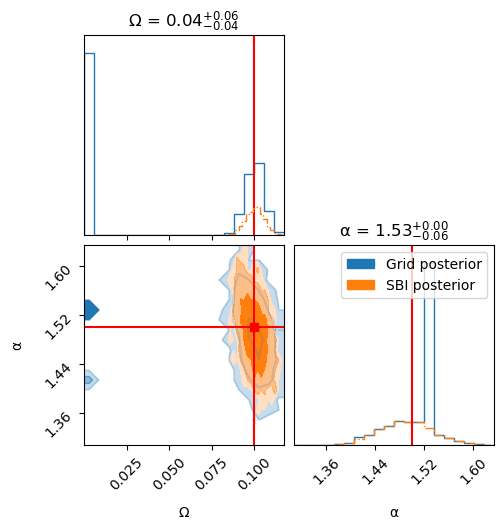

In [35]:
# ----------------------------
# Corner plot
# ----------------------------
figure = corner.corner(
    df_all[["Omega", "alpha"]].values,
    labels=["Ω", "α"],
    color="C0",  # default color; we'll overlay SBI manually
    show_titles=True,
    title_kwargs={"fontsize": 12},
    truths=theta_true[0],
    truth_color="red",
    plot_datapoints=False,
    fill_contours=True,
    contour_kwargs={"alpha":0.2, "colors":["C0"]},
    levels=(0.68, 0.95, 0.997),
)

# Overlay SBI posterior samples in a different color

corner.corner(
    df_sbi[["Omega", "alpha"]].values,
    fig=figure,
    color="C1",
    plot_datapoints=False,
    fill_contours=True,
    contour_kwargs={"alpha":0, "colors":["C1"], "linestyles": ["--"]},
    hist_kwargs={
    "histtype": "step",
    "linestyle": "-.",       # dash-dot for SBI 1D marginal
    "color": "C1",
    "linewidth": 1
    },
    levels=(0.68, 0.95, 0.997),
)

# Add legend manually
import matplotlib.patches as mpatches
patch_grid = mpatches.Patch(color='C0', label='Grid posterior')
patch_sbi  = mpatches.Patch(color='C1', label='SBI posterior')
plt.legend(handles=[patch_grid, patch_sbi], loc='upper right')

plt.show()



## MCMC